# Projeto: Análise de Audiência das Notícias do Palmeiras com PLN e Machine Learning

Este notebook continua o trabalho de PLN que você já fez e transforma a base em um projeto completo de análise.

A ideia principal é responder:

- Quais notícias geram mais visitas?
- Quais palavras aparecem mais nas notícias de alta audiência?
- Quais temas existem nas notícias?
- Alguns temas têm mais visitas do que outros?
- É possível prever se uma notícia terá alta audiência usando título, texto e data?

A base esperada deve ter, pelo menos, as colunas:

- `titulo`
- `texto`
- `data`
- `visitas`

Se sua base tiver outras colunas, elas podem continuar no DataFrame sem problema.

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path
from unidecode import unidecode

import nltk
from nltk.tokenize import wordpunct_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

nltk.download("stopwords", quiet=True)

True

## 2. Leitura da base

A célula abaixo tenta ler sua base no mesmo caminho usado no seu notebook original.

Caso o caminho seja diferente, altere a variável `CAMINHO_BASE`.

In [2]:
CAMINHO_BASE = "../Webscraping/data/noticias_palmeiras (1).csv"

df = pd.read_csv(CAMINHO_BASE, sep=";")

print(df.shape)
df.head()

(2000, 4)


,titulo,data,texto,visitas
0,STJD indefere pedido de suspensão e Abel Ferre...,11/4/2026 16:47,O Palmeiras terá uma nova rodada de desafios n...,141
1,Nubank Anuncia Amistoso Imperdível: Palmeiras ...,11/4/2026 16:47,O Nubank está explorando a possibilidade de or...,129
2,STJD Recusa Suspensão de Abel Ferreira; Palmei...,11/4/2026 16:47,A Sociedade Esportiva Palmeiras manifestou sua...,105
3,Palmeiras encerra treinos para o Dérbi com Vit...,11/4/2026 14:27,"Na manhã deste sábado (11), a Academia de Fute...",276
4,Messi Pode Anunciar Amistoso Histórico em São ...,11/4/2026 14:07,"A co-fundadora do Nubank, Cristina Junqueira, ...",246


## 3. Conferência e preparação inicial

In [3]:
# Padronizando nomes das colunas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Garantindo que as principais colunas existem
colunas_necessarias = ["titulo", "texto", "data", "visitas"]
faltantes = [col for col in colunas_necessarias if col not in df.columns]

if faltantes:
    raise ValueError(f"Colunas ausentes na base: {faltantes}")

# Tipos básicos
df["titulo"] = df["titulo"].astype(str)
df["texto"] = df["texto"].astype(str)

# Data
df["data"] = pd.to_datetime(df["data"], errors="coerce", dayfirst=True)

# Visitas
df["visitas"] = (
    df["visitas"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)

df["visitas"] = pd.to_numeric(df["visitas"], errors="coerce")

# Removendo linhas sem informação essencial
df = df.dropna(subset=["data", "visitas"]).copy()

# Para modelos, é comum usar log das visitas, porque audiência costuma ser muito assimétrica
df["log_visitas"] = np.log1p(df["visitas"])

print(df.shape)
df[["titulo", "data", "visitas", "log_visitas"]].head()

(2000, 5)


,titulo,data,visitas,log_visitas
0,STJD indefere pedido de suspensão e Abel Ferre...,2026-04-11 16:47:00,141,4.955827
1,Nubank Anuncia Amistoso Imperdível: Palmeiras ...,2026-04-11 16:47:00,129,4.867534
2,STJD Recusa Suspensão de Abel Ferreira; Palmei...,2026-04-11 16:47:00,105,4.663439
3,Palmeiras encerra treinos para o Dérbi com Vit...,2026-04-11 14:27:00,276,5.624018
4,Messi Pode Anunciar Amistoso Histórico em São ...,2026-04-11 14:07:00,246,5.509388


## 4. Limpeza textual

Essa parte aproveita a mesma lógica do seu notebook original:

- coloca tudo em minúsculo;
- remove acentos;
- tokeniza;
- remove pontuação;
- remove stopwords;
- remove tokens muito curtos.

In [4]:
stopwords_pt = stopwords.words("portuguese")
stopwords_pt = [unidecode(palavra) for palavra in stopwords_pt]
stopwords_pt = set(stopwords_pt)

# Palavras muito frequentes no contexto e que podem atrapalhar a análise
stopwords_extra = {
    "palmeiras", "verdao", "alviverde", "clube", "time",
    "noticia", "noticias", "diz", "sobre", "apos", "ainda"
}

stopwords_final = stopwords_pt.union(stopwords_extra)


def limpar_texto(texto):
    texto = str(texto).lower()
    texto = unidecode(texto)
    tokens = wordpunct_tokenize(texto)
    tokens = [token for token in tokens if token.isalpha()]
    tokens = [token for token in tokens if token not in stopwords_final]
    tokens = [token for token in tokens if len(token) >= 3]
    return " ".join(tokens)


df["titulo_limpo"] = df["titulo"].apply(limpar_texto)
df["texto_limpo"] = df["texto"].apply(limpar_texto)

# Texto combinado: título costuma ter muito poder explicativo para visitas
df["texto_modelo"] = df["titulo_limpo"] + " " + df["texto_limpo"]

df[["titulo", "titulo_limpo", "texto_limpo"]].head()

,titulo,titulo_limpo,texto_limpo
0,STJD indefere pedido de suspensão e Abel Ferre...,stjd indefere pedido suspensao abel ferreira d...,nova rodada desafios campeonato brasileiro enf...
1,Nubank Anuncia Amistoso Imperdível: Palmeiras ...,nubank anuncia amistoso imperdivel enfrentara ...,nubank explorando possibilidade organizar amis...
2,STJD Recusa Suspensão de Abel Ferreira; Palmei...,stjd recusa suspensao abel ferreira contesta d...,sociedade esportiva manifestou insatisfacao re...
3,Palmeiras encerra treinos para o Dérbi com Vit...,encerra treinos derbi vitor roque duvida,manha deste sabado academia futebol palco ulti...
4,Messi Pode Anunciar Amistoso Histórico em São ...,messi pode anunciar amistoso historico paulo,fundadora nubank cristina junqueira revelou re...


## 5. Criação de variáveis explicativas

Aqui criamos variáveis simples, mas muito úteis:

- dia da semana;
- mês;
- hora;
- tamanho do título;
- quantidade de palavras no título;
- tamanho do texto;
- quantidade de palavras do texto.

Essas variáveis ajudam a investigar se audiência depende de data, horário e estrutura da notícia.

In [5]:
df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["dia"] = df["data"].dt.day
df["dia_semana"] = df["data"].dt.dayofweek  # segunda=0, domingo=6
df["hora"] = df["data"].dt.hour
df["fim_de_semana"] = df["dia_semana"].isin([5, 6]).astype(int)

df["qtd_caracteres_titulo"] = df["titulo"].str.len()
df["qtd_palavras_titulo"] = df["titulo"].str.split().str.len()
df["qtd_caracteres_texto"] = df["texto"].str.len()
df["qtd_palavras_texto"] = df["texto"].str.split().str.len()

df[[
    "titulo", "data", "visitas", "dia_semana", "hora",
    "qtd_palavras_titulo", "qtd_palavras_texto"
]].head()

,titulo,data,visitas,dia_semana,hora,qtd_palavras_titulo,qtd_palavras_texto
0,STJD indefere pedido de suspensão e Abel Ferre...,2026-04-11 16:47:00,141,5,16,16,319.0
1,Nubank Anuncia Amistoso Imperdível: Palmeiras ...,2026-04-11 16:47:00,129,5,16,13,265.0
2,STJD Recusa Suspensão de Abel Ferreira; Palmei...,2026-04-11 16:47:00,105,5,16,11,338.0
3,Palmeiras encerra treinos para o Dérbi com Vit...,2026-04-11 14:27:00,276,5,14,12,387.0
4,Messi Pode Anunciar Amistoso Histórico em São ...,2026-04-11 14:07:00,246,5,14,10,374.0


## 6. Análise descritiva da audiência

In [6]:
df["visitas"].describe()

count     2000.000000
mean      1679.715000
std       3290.181521
min        105.000000
25%        693.000000
50%        978.000000
75%       1662.000000
max      85839.000000
Name: visitas, dtype: float64

In [7]:
top_noticias = (
    df[["titulo", "data", "visitas"]]
    .sort_values("visitas", ascending=False)
    .head(10)
)

top_noticias

,titulo,data,visitas
1673,Mais reforços a caminho? Palmeiras aproveita f...,2026-02-10 17:02:00,85839
1651,REFORÇO DE PESO! Palmeiras acerta a contrataçã...,2026-02-11 07:42:00,68550
914,PREMIAÇÃO ASTRONÔMICA: Confira quanto o Palmei...,2026-03-09 08:24:00,29481
1477,Palmeiras recebe proposta astronômica por Vito...,2026-02-19 08:21:00,27657
1367,Venda milionária? Palmeiras recebe propostas p...,2026-02-23 16:26:00,23760
743,Palmeiras negocia pacote do Zenit com Wendel e...,2026-03-15 14:53:00,21999
165,Palmeiras posta vídeo fazendo provocação a Rog...,2026-04-06 13:27:00,21939
1038,Presidente dos Estados Unidos exalta o Palmeir...,2026-03-06 10:23:00,20889
1567,Palmeiras e Guarani se enfrentam na 8ª rodada ...,2026-02-14 07:22:00,20688
227,Bahia x Palmeiras; Saiba onde assistir,2026-04-04 16:06:00,19209


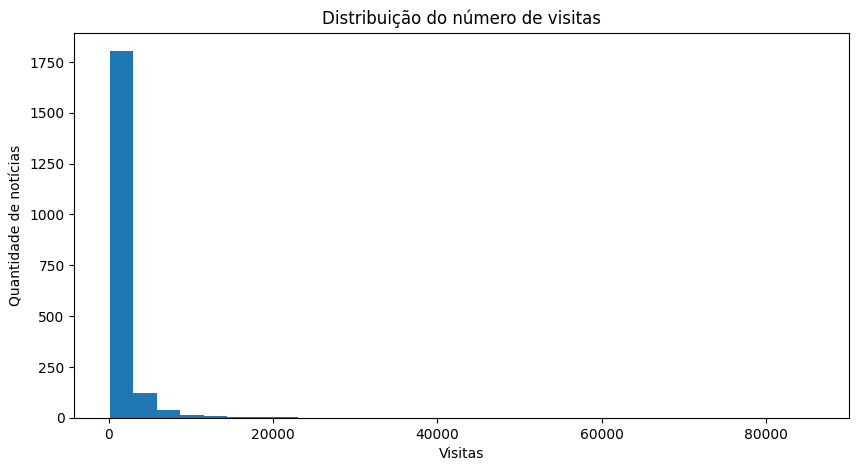

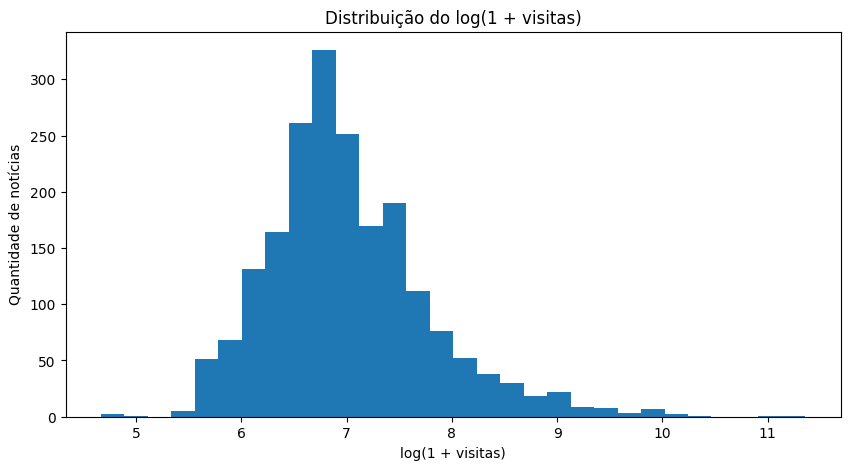

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df["visitas"], bins=30)
plt.title("Distribuição do número de visitas")
plt.xlabel("Visitas")
plt.ylabel("Quantidade de notícias")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["log_visitas"], bins=30)
plt.title("Distribuição do log(1 + visitas)")
plt.xlabel("log(1 + visitas)")
plt.ylabel("Quantidade de notícias")
plt.show()

### Visitas ao longo do tempo

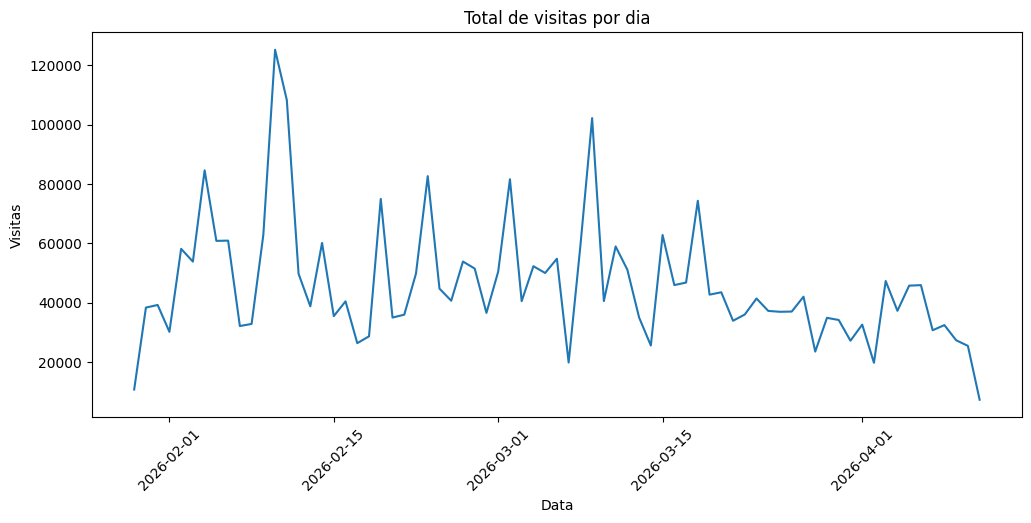

In [9]:
visitas_dia = (
    df
    .set_index("data")
    .resample("D")["visitas"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(visitas_dia["data"], visitas_dia["visitas"])
plt.title("Total de visitas por dia")
plt.xlabel("Data")
plt.ylabel("Visitas")
plt.xticks(rotation=45)
plt.show()

### Média de visitas por dia da semana e horário

In [10]:
mapa_dias = {
    0: "Segunda",
    1: "Terça",
    2: "Quarta",
    3: "Quinta",
    4: "Sexta",
    5: "Sábado",
    6: "Domingo"
}

media_dia_semana = (
    df
    .groupby("dia_semana")["visitas"]
    .mean()
    .rename(index=mapa_dias)
    .sort_values(ascending=False)
)

media_dia_semana

dia_semana
Terça      2151.681818
Quarta     1851.646465
Segunda    1741.078947
Sábado     1651.492958
Sexta      1510.878594
Domingo    1498.736301
Quinta     1481.015480
Name: visitas, dtype: float64

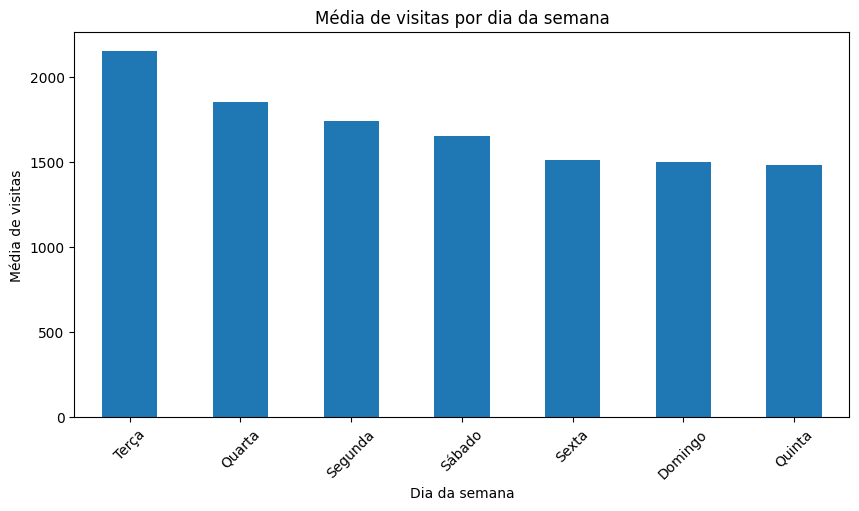

In [11]:
plt.figure(figsize=(10, 5))
media_dia_semana.plot(kind="bar")
plt.title("Média de visitas por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Média de visitas")
plt.xticks(rotation=45)
plt.show()

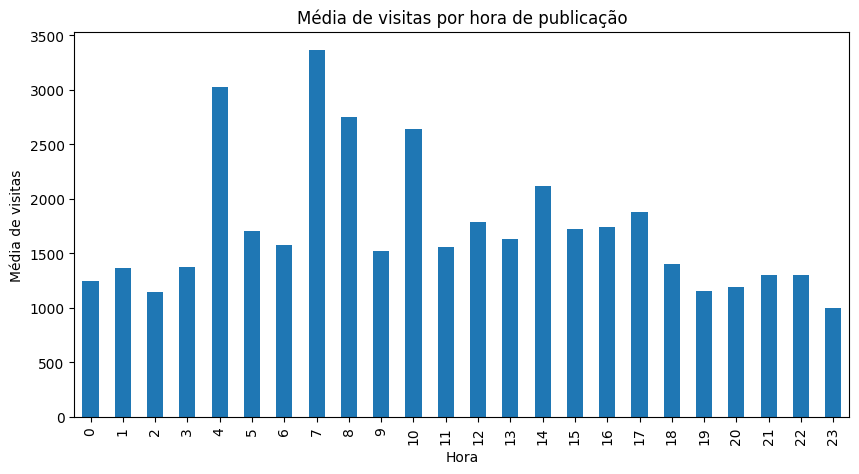

In [12]:
media_hora = df.groupby("hora")["visitas"].mean()

plt.figure(figsize=(10, 5))
media_hora.plot(kind="bar")
plt.title("Média de visitas por hora de publicação")
plt.xlabel("Hora")
plt.ylabel("Média de visitas")
plt.show()

## 7. Notícias de alta audiência

Vamos criar uma variável-alvo:

- `alta_audiencia = 1`: notícia no top 25% de visitas;
- `alta_audiencia = 0`: demais notícias.

Isso transforma o problema em uma classificação: prever se uma notícia tende a ser de alta audiência.

In [13]:
limite_alta_audiencia = df["visitas"].quantile(0.75)

df["alta_audiencia"] = (df["visitas"] >= limite_alta_audiencia).astype(int)

print("Limite para alta audiência:", limite_alta_audiencia)
df["alta_audiencia"].value_counts(normalize=True)

Limite para alta audiência: 1662.0


alta_audiencia
0    0.7495
1    0.2505
Name: proportion, dtype: float64

## 8. Palavras mais frequentes nas notícias

Aqui usamos `CountVectorizer`, parecido com seu Bag of Words, mas já com alguns filtros:

- `min_df=3`: palavra precisa aparecer em pelo menos 3 notícias;
- `max_df=0.85`: remove palavras que aparecem em notícias demais;
- `ngram_range=(1,2)`: considera palavras isoladas e pares de palavras.

In [14]:
count_vectorizer = CountVectorizer(
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2)
)

matriz_bow = count_vectorizer.fit_transform(df["texto_modelo"])

freq_palavras = pd.DataFrame({
    "termo": count_vectorizer.get_feature_names_out(),
    "frequencia": np.asarray(matriz_bow.sum(axis=0)).ravel()
}).sort_values("frequencia", ascending=False)

freq_palavras.head(30)

,termo,frequencia
10291,equipe,3800
15665,jogo,2931
9,abel,2893
3918,campeonato,2771
12039,ferreira,2354
9363,elenco,2325
38,abel ferreira,2221
6317,contra,2092
7862,desempenho,1975
19844,partida,1870


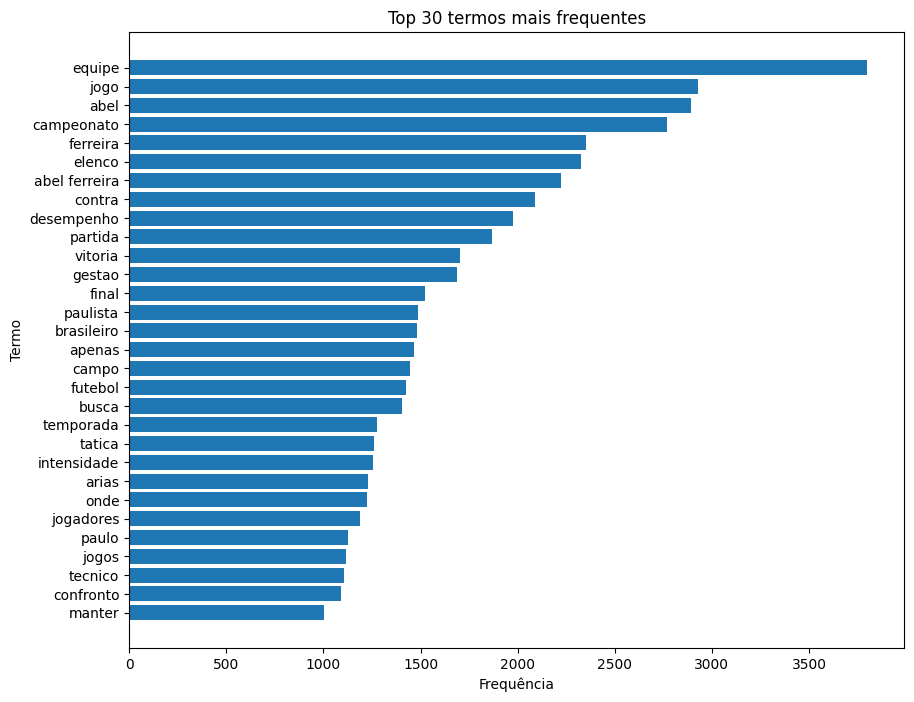

In [15]:
top_30 = freq_palavras.head(30).sort_values("frequencia")

plt.figure(figsize=(10, 8))
plt.barh(top_30["termo"], top_30["frequencia"])
plt.title("Top 30 termos mais frequentes")
plt.xlabel("Frequência")
plt.ylabel("Termo")
plt.show()

## 9. Palavras associadas à alta audiência

Agora comparamos a presença média dos termos em:

- notícias de alta audiência;
- demais notícias.

A métrica `diferenca` indica quais termos aparecem proporcionalmente mais nas notícias de alta audiência.

In [16]:
bow_df = pd.DataFrame(
    matriz_bow.toarray(),
    columns=count_vectorizer.get_feature_names_out()
)

presenca = (bow_df > 0).astype(int)
presenca["alta_audiencia"] = df["alta_audiencia"].values

media_alta = presenca[presenca["alta_audiencia"] == 1].drop(columns="alta_audiencia").mean()
media_baixa = presenca[presenca["alta_audiencia"] == 0].drop(columns="alta_audiencia").mean()

comparacao_termos = pd.DataFrame({
    "termo": media_alta.index,
    "presenca_alta": media_alta.values,
    "presenca_baixa": media_baixa.values
})

comparacao_termos["diferenca"] = (
    comparacao_termos["presenca_alta"] - comparacao_termos["presenca_baixa"]
)

comparacao_termos.sort_values("diferenca", ascending=False).head(30)

,termo,presenca_alta,presenca_baixa,diferenca
8714,diretoria,0.251497,0.121414,0.130083
17612,mercado,0.225549,0.105404,0.120145
3356,brasileirao,0.315369,0.206137,0.109232
17754,milhoes,0.237525,0.128753,0.108772
15393,janela,0.141717,0.044696,0.097020
19579,palavras chave,0.205589,0.110073,0.095515
19578,palavras,0.215569,0.120080,0.095489
26932,transferencias,0.133733,0.042028,0.091705
4608,chave,0.281437,0.197465,0.083972
2400,atleta,0.251497,0.172115,0.079382


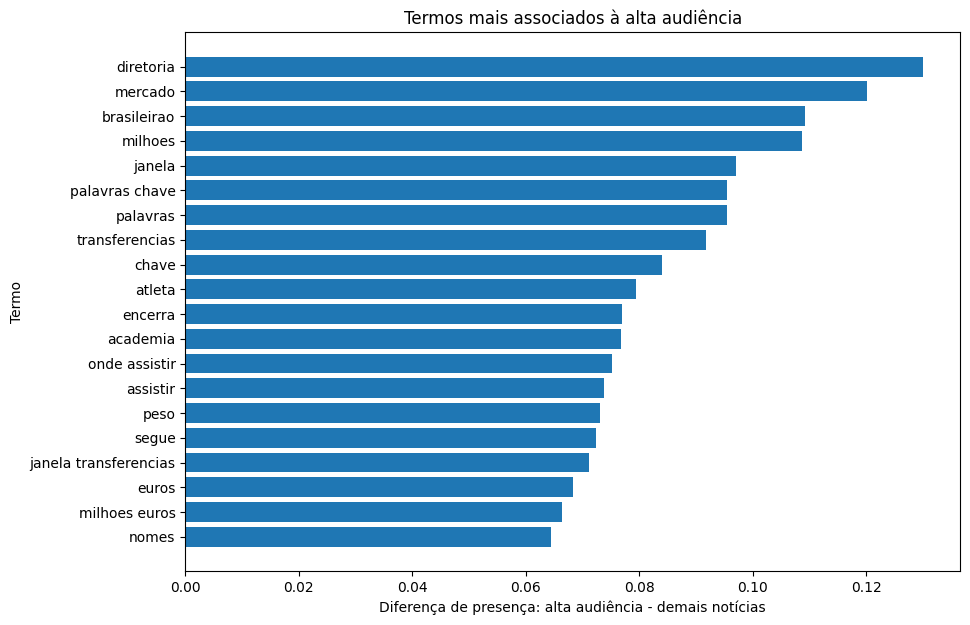

In [17]:
top_dif = comparacao_termos.sort_values("diferenca", ascending=False).head(20)
top_dif = top_dif.sort_values("diferenca")

plt.figure(figsize=(10, 7))
plt.barh(top_dif["termo"], top_dif["diferenca"])
plt.title("Termos mais associados à alta audiência")
plt.xlabel("Diferença de presença: alta audiência - demais notícias")
plt.ylabel("Termo")
plt.show()

## 10. Agrupamento de notícias por tema com TF-IDF + K-Means

Aqui fazemos uma análise não supervisionada.

Objetivo:

> Agrupar notícias parecidas e depois ver qual grupo tem maior média de visitas.

A interpretação dos grupos é feita olhando as palavras mais importantes de cada cluster.

In [18]:
tfidf_cluster = TfidfVectorizer(
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
    max_features=2000
)

X_tfidf_cluster = tfidf_cluster.fit_transform(df["texto_modelo"])

# Testando alguns valores de k
resultados_k = []

for k in range(3, 9):
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo_k.fit_predict(X_tfidf_cluster)
    sil = silhouette_score(X_tfidf_cluster, labels)
    resultados_k.append({"k": k, "silhouette": sil})

pd.DataFrame(resultados_k)

,k,silhouette
0,3,0.014410
1,4,0.020925
2,5,0.020811
3,6,0.023555
4,7,0.025239
5,8,0.027518


In [19]:
# Escolha o k com base na tabela acima.
# Se quiser simplificar, comece com 5 clusters.
K_ESCOLHIDO = 5

kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_tfidf_cluster)

df["cluster"].value_counts().sort_index()

cluster
0    575
1    518
2    462
3    401
4     44
Name: count, dtype: int64

In [20]:
termos = np.array(tfidf_cluster.get_feature_names_out())

top_termos_clusters = []

for cluster_id in range(K_ESCOLHIDO):
    centroide = kmeans.cluster_centers_[cluster_id]
    indices_top = centroide.argsort()[::-1][:15]
    termos_top = termos[indices_top]

    top_termos_clusters.append({
        "cluster": cluster_id,
        "top_termos": ", ".join(termos_top)
    })

pd.DataFrame(top_termos_clusters)

,cluster,top_termos
0,0,"abel, equipe, novorizontino, final, ferreira, ..."
1,1,"equipe, vitoria, campeonato, partida, jogo, go..."
2,2,"milhoes, arias, mercado, futebol, veiga, jogad..."
3,3,"paulinho, roque, vitor roque, vitor, piquerez,..."
4,4,"pic twitter, pic, twitter, diario, confira, to..."


In [21]:
resumo_clusters = (
    df
    .groupby("cluster")
    .agg(
        qtd_noticias=("titulo", "count"),
        visitas_media=("visitas", "mean"),
        visitas_mediana=("visitas", "median"),
        visitas_total=("visitas", "sum"),
        perc_alta_audiencia=("alta_audiencia", "mean")
    )
    .sort_values("visitas_media", ascending=False)
)

resumo_clusters

,qtd_noticias,visitas_media,visitas_mediana,visitas_total,perc_alta_audiencia
cluster,,,,,
4,44,3315.613636,2685.0,145887,0.795455
2,462,2412.409091,1200.0,1114533,0.331169
0,575,1477.262609,921.0,849426,0.193043
3,401,1464.149626,990.0,587124,0.284289
1,518,1278.880309,835.5,662460,0.169884


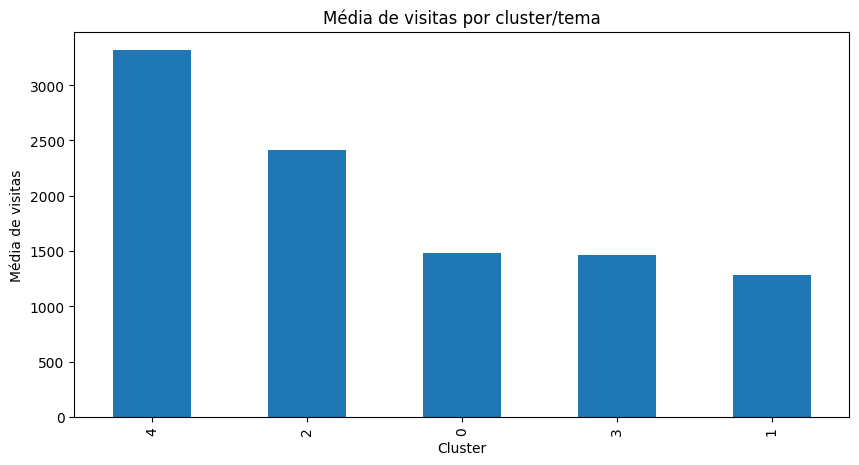

In [22]:
plt.figure(figsize=(10, 5))
resumo_clusters["visitas_media"].plot(kind="bar")
plt.title("Média de visitas por cluster/tema")
plt.xlabel("Cluster")
plt.ylabel("Média de visitas")
plt.show()

### Exemplos de notícias por cluster

Use esta parte para interpretar os temas manualmente.

Depois de olhar os títulos, você pode criar nomes para os clusters, por exemplo:

- Mercado da bola;
- Abel Ferreira;
- Jogos e escalação;
- Lesões;
- Diretoria/bastidores.

In [23]:
for cluster_id in sorted(df["cluster"].unique()):
    print("=" * 80)
    print(f"CLUSTER {cluster_id}")
    print("=" * 80)

    exemplos = (
        df[df["cluster"] == cluster_id]
        .sort_values("visitas", ascending=False)
        [["titulo", "visitas"]]
        .head(8)
    )

    for _, linha in exemplos.iterrows():
        print(f"- ({linha['visitas']:.0f} visitas) {linha['titulo']}")
    print()

CLUSTER 0
- (29481 visitas) PREMIAÇÃO ASTRONÔMICA: Confira quanto o Palmeiras ganhou com o Paulistão
- (18255 visitas) Semifinal à vista: veja quem pode cruzar o caminho do Palmeiras no Paulistão
- (17763 visitas) Emprestado pelo Palmeiras, Rômulo brilha no Novorizontino
- (16107 visitas) Palmeiras se anima com possível retorno de craque para a final do Paulistão!!
- (14691 visitas) Novorizontino enfrenta multa para contar com Rômulo na decisão contra o Palmeiras no Paulistão
- (14139 visitas) FPF define data e horário do Choque-Rei na semifinal do Paulistão
- (12645 visitas) Palmeiras x Guarani; Saiba onde assistir
- (9783 visitas) Abel explica saída de Vitor Roque e comenta novas regras da CBF

CLUSTER 1
- (21939 visitas) Palmeiras posta vídeo fazendo provocação a Rogério Ceni após vitória sobre o Bahia no Brasileirão
- (20688 visitas) Palmeiras e Guarani se enfrentam na 8ª rodada do Brasileirão: Confira onde assistir ao duelo
- (19209 visitas) Bahia x Palmeiras; Saiba onde assistir


## 11. Modelo de classificação: prever alta audiência

Agora treinamos um modelo para prever se uma notícia está entre as mais visitadas.

Variáveis usadas:

- texto do título + corpo da notícia via TF-IDF;
- dia da semana;
- hora;
- fim de semana;
- tamanho do título;
- tamanho do texto;
- cluster.

In [24]:
features_numericas = [
    "dia_semana",
    "hora",
    "fim_de_semana",
    "qtd_caracteres_titulo",
    "qtd_palavras_titulo",
    "qtd_caracteres_texto",
    "qtd_palavras_texto",
    "cluster"
]

X = df[["texto_modelo"] + features_numericas].copy()
y = df["alta_audiencia"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

preprocessamento = ColumnTransformer(
    transformers=[
        (
            "texto",
            TfidfVectorizer(
                min_df=3,
                max_df=0.85,
                ngram_range=(1, 2),
                max_features=3000
            ),
            "texto_modelo"
        ),
        (
            "numericas",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            features_numericas
        )
    ]
)

modelo_classificacao = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

modelo_classificacao.fit(X_train, y_train)

pred = modelo_classificacao.predict(X_test)
proba = modelo_classificacao.predict_proba(X_test)[:, 1]

print("Acurácia:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("AUC:", roc_auc_score(y_test, proba))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, pred))

print("\nRelatório:")
print(classification_report(y_test, pred))

Acurácia: 0.724
Precision: 0.4648648648648649
Recall: 0.688
F1: 0.5548387096774193
AUC: 0.7893333333333332

Matriz de confusão:
[[276  99]
 [ 39  86]]

Relatório:
              precision    recall  f1-score   support

           0       0.88      0.74      0.80       375
           1       0.46      0.69      0.55       125

    accuracy                           0.72       500
   macro avg       0.67      0.71      0.68       500
weighted avg       0.77      0.72      0.74       500



### Interpretação dos termos do modelo

Como usamos regressão logística, conseguimos olhar quais termos aumentam mais a chance estimada de alta audiência.

Coeficiente positivo: termo associado a maior chance de alta audiência.

Coeficiente negativo: termo associado a menor chance de alta audiência.

In [25]:
# Recuperando nomes das variáveis após o preprocessamento
modelo_logistico = modelo_classificacao.named_steps["modelo"]
preprocessador = modelo_classificacao.named_steps["preprocessamento"]

nomes_texto = (
    preprocessador
    .named_transformers_["texto"]
    .get_feature_names_out()
)

nomes_features = list(nomes_texto) + features_numericas

coeficientes = pd.DataFrame({
    "variavel": nomes_features,
    "coeficiente": modelo_logistico.coef_[0]
})

print("Termos/variáveis mais associados à alta audiência:")
display(coeficientes.sort_values("coeficiente", ascending=False).head(30))

print("Termos/variáveis menos associados à alta audiência:")
display(coeficientes.sort_values("coeficiente", ascending=True).head(30))

Termos/variáveis mais associados à alta audiência:


,variavel,coeficiente
2075,paulo,1.273488
1355,futebol,1.180463
1577,janela,1.126108
332,brasileirao,1.052852
218,assistir,0.950198
1909,nino,0.950031
1984,onde assistir,0.926781
1765,mata,0.926230
899,diretoria,0.912530
1798,mercado,0.912034


Termos/variáveis menos associados à alta audiência:


,variavel,coeficiente
381,campeonato,-1.216743
1069,equipe,-1.101590
811,desempenho,-1.079232
2043,partida,-1.050000
710,crucial,-1.047609
2968,vitorias,-0.954139
2212,prepara,-0.896585
382,campeonato brasileiro,-0.892806
398,capivariano,-0.888628
2168,posicao,-0.861648


## 12. Modelo de regressão: prever número de visitas

Além de classificar alta audiência, também podemos tentar prever o volume de visitas.

Como visitas costuma ser uma variável muito assimétrica, o alvo usado será `log(1 + visitas)`.

In [27]:
X_reg = df[["texto_modelo"] + features_numericas].copy()
y_reg = df["log_visitas"].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

modelo_regressao = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("modelo", Ridge(alpha=1.0))
])

modelo_regressao.fit(X_train_reg, y_train_reg)

pred_log = modelo_regressao.predict(X_test_reg)

mae_log = mean_absolute_error(y_test_reg, pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_reg, pred_log))
r2 = r2_score(y_test_reg, pred_log)

print("MAE no log:", mae_log)
print("RMSE no log:", rmse_log)
print("R²:", r2)

# Convertendo de volta para escala de visitas
pred_visitas = np.expm1(pred_log)
real_visitas = np.expm1(y_test_reg)

mae_visitas = mean_absolute_error(real_visitas, pred_visitas)
rmse_visitas = np.sqrt(mean_squared_error(real_visitas, pred_visitas))

print("\nMAE em visitas:", mae_visitas)
print("RMSE em visitas:", rmse_visitas)

MAE no log: 0.46440899185144835
RMSE no log: 0.6193153297696755
R²: 0.29316047822939895

MAE em visitas: 891.0845898082708
RMSE em visitas: 4091.2006809126165


In [28]:
comparacao_regressao = pd.DataFrame({
    "titulo": X_test_reg["texto_modelo"].index.map(df["titulo"]),
    "visitas_reais": real_visitas,
    "visitas_previstas": pred_visitas
})

comparacao_regressao.sort_values("visitas_reais", ascending=False).head(20)

,titulo,visitas_reais,visitas_previstas
1673,Mais reforços a caminho? Palmeiras aproveita f...,85839.0,3219.337528
743,Palmeiras negocia pacote do Zenit com Wendel e...,21999.0,2652.766430
1567,Palmeiras e Guarani se enfrentam na 8ª rodada ...,20688.0,1372.840871
1259,BOMBA: Palmeiras acerta bases com Nino e avanç...,13740.0,1688.657391
886,Palmeiras encara o Olímpia na Libertadores Sub...,10098.0,1656.904736
307,Palmeiras enfrenta o Grêmio no Brasileirão; Sa...,9024.0,1202.415129
415,Artilheiro volta aos treinos e vira trunfo par...,8487.0,1394.796083
651,Campeão em 2015 pelo Palmeiras brilha na Arábi...,7647.0,1501.681565
519,Rumo ao penta! Palmeiras conhece adversário da...,7581.0,2875.132477
712,Paulinho volta aos treinos e revela quando ira...,7365.0,2807.257650


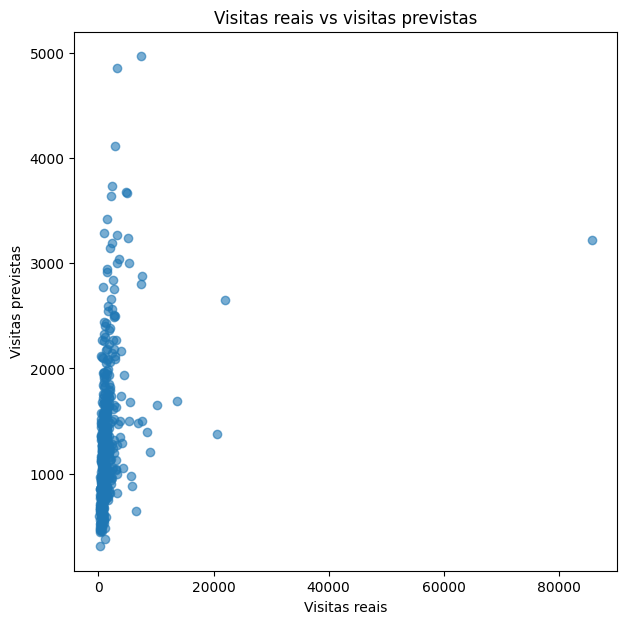

In [29]:
plt.figure(figsize=(7, 7))
plt.scatter(real_visitas, pred_visitas, alpha=0.6)
plt.title("Visitas reais vs visitas previstas")
plt.xlabel("Visitas reais")
plt.ylabel("Visitas previstas")
plt.show()

## 13. Conclusões automáticas para ajudar na apresentação

Depois de rodar tudo, esta célula gera alguns pontos principais para você comentar no trabalho.

In [30]:
print("RESUMO DO PROJETO")
print("=" * 80)

print(f"Total de notícias analisadas: {len(df):,}")
print(f"Total de visitas: {df['visitas'].sum():,.0f}")
print(f"Média de visitas por notícia: {df['visitas'].mean():,.2f}")
print(f"Mediana de visitas por notícia: {df['visitas'].median():,.2f}")
print(f"Limite usado para alta audiência, top 25%: {limite_alta_audiencia:,.0f} visitas")

print("\nTop 5 notícias mais visitadas:")
for _, linha in top_noticias.head(5).iterrows():
    print(f"- {linha['titulo']} ({linha['visitas']:.0f} visitas)")

print("\nTop 10 termos mais associados à alta audiência:")
for _, linha in comparacao_termos.sort_values("diferenca", ascending=False).head(10).iterrows():
    print(f"- {linha['termo']}")

print("\nClusters com maior média de visitas:")
display(resumo_clusters.head())

print("\nDesempenho do modelo de classificação:")
print(f"- Acurácia: {accuracy_score(y_test, pred):.3f}")
print(f"- Precision: {precision_score(y_test, pred):.3f}")
print(f"- Recall: {recall_score(y_test, pred):.3f}")
print(f"- F1: {f1_score(y_test, pred):.3f}")
print(f"- AUC: {roc_auc_score(y_test, proba):.3f}")

RESUMO DO PROJETO
Total de notícias analisadas: 2,000
Total de visitas: 3,359,430
Média de visitas por notícia: 1,679.71
Mediana de visitas por notícia: 978.00
Limite usado para alta audiência, top 25%: 1,662 visitas

Top 5 notícias mais visitadas:
- Mais reforços a caminho? Palmeiras aproveita fim da janela europeia para buscar zagueiro (85839 visitas)
- REFORÇO DE PESO! Palmeiras acerta a contratação de joia da base de clube do exterior (68550 visitas)
- PREMIAÇÃO ASTRONÔMICA: Confira quanto o Palmeiras ganhou com o Paulistão (29481 visitas)
- Palmeiras recebe proposta astronômica por Vitor Roque (27657 visitas)
- Venda milionária? Palmeiras recebe propostas por craque após grandes atuações no Paulistão! (23760 visitas)

Top 10 termos mais associados à alta audiência:
- diretoria
- mercado
- brasileirao
- milhoes
- janela
- palavras chave
- palavras
- transferencias
- chave
- atleta

Clusters com maior média de visitas:


,qtd_noticias,visitas_media,visitas_mediana,visitas_total,perc_alta_audiencia
cluster,,,,,
4,44,3315.613636,2685.0,145887,0.795455
2,462,2412.409091,1200.0,1114533,0.331169
0,575,1477.262609,921.0,849426,0.193043
3,401,1464.149626,990.0,587124,0.284289
1,518,1278.880309,835.5,662460,0.169884



Desempenho do modelo de classificação:
- Acurácia: 0.724
- Precision: 0.465
- Recall: 0.688
- F1: 0.555
- AUC: 0.789


## 14. Salvando bases finais

Esta parte salva:

- base tratada;
- resumo dos clusters;
- termos associados à alta audiência;
- coeficientes do modelo.

In [ ]:
pasta_saida = Path("../dados_projeto_palmeiras")
pasta_saida.mkdir(exist_ok=True)

df.to_csv(pasta_saida / "base_tratada_noticias_palmeiras.csv", index=False)
resumo_clusters.to_csv(pasta_saida / "resumo_clusters.csv")
comparacao_termos.to_csv(pasta_saida / "termos_alta_audiencia.csv", index=False)
coeficientes.to_csv(pasta_saida / "coeficientes_modelo_classificacao.csv", index=False)

print("Arquivos salvos em:", pasta_saida)

# Sugestão de narrativa para o trabalho

Você pode apresentar o projeto assim:

> O objetivo foi analisar notícias do Palmeiras e entender quais características textuais e temporais estão associadas a maior audiência. Para isso, foram aplicadas técnicas de Processamento de Linguagem Natural, análise exploratória, agrupamento não supervisionado e modelos preditivos.

Estrutura recomendada:

1. **Base de dados**: explicar colunas disponíveis e período analisado.
2. **Tratamento textual**: limpeza, remoção de stopwords, Bag of Words e TF-IDF.
3. **Análise exploratória**: distribuição de visitas, dias/horários e notícias mais acessadas.
4. **Palavras relevantes**: termos mais frequentes e termos associados à alta audiência.
5. **Agrupamento por temas**: clusters de notícias e média de visitas por tema.
6. **Modelo preditivo**: previsão de alta audiência com regressão logística.
7. **Conclusão**: temas/palavras que mais engajam e limites do modelo.

Ponto importante:

> O modelo não deve ser visto como uma previsão perfeita de visitas, mas como uma forma de identificar padrões de audiência e apoiar decisões editoriais.

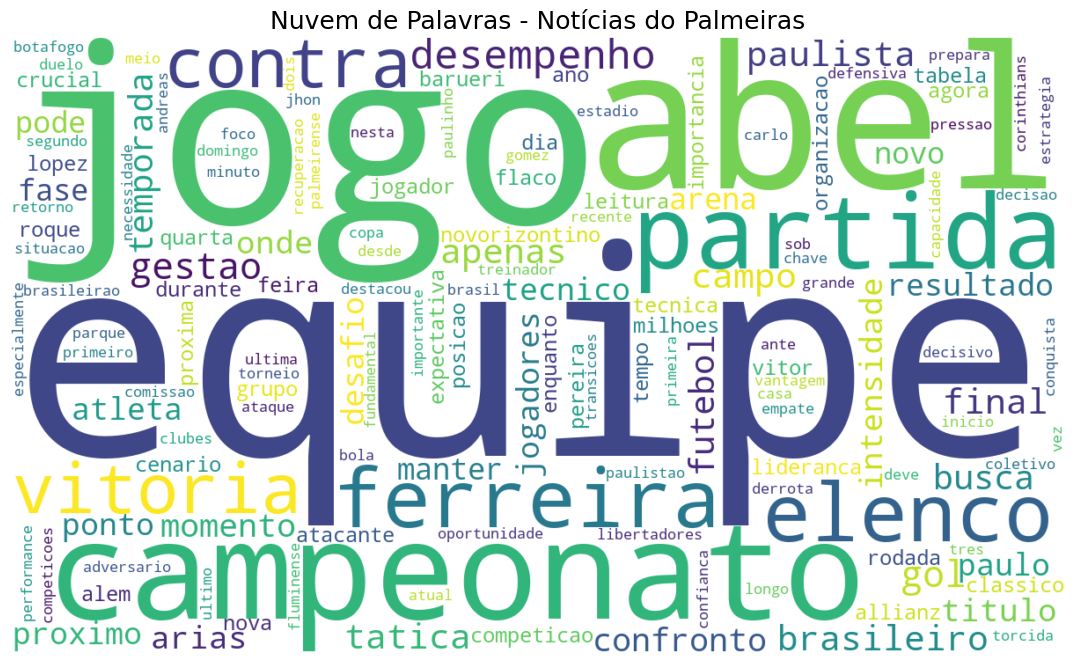

In [36]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Junta todos os textos já limpos
texto_geral = " ".join(df["texto_modelo"].dropna())

# Cria a nuvem de palavras
wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    max_words=150,
    collocations=False
).generate(texto_geral)

# Plota
plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras - Notícias do Palmeiras", fontsize=18)
plt.show()